In [1]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

### **Predicting Freight Cost**
#### **Objective**: Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

- Freight is a non-trivial component of landed cost.
- Poor freight estimates distort margin and inventory planning.
- Automating freight estimation helps procurement teams forecast true cost before invoice arrival.

In [25]:
conn = sqlite3.connect(r"C:\Users\bhuvancw\OneDrive\Desktop\Data Science Projects\Machine Learning\Vendor Invoice ML Project\data\inventory.db")

tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [3]:
from IPython.display import display

for table in tables['name']:
    pd.set_option('display.max_columns', None)
    print("Table:", table)
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    display(df)

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
vendor_df = pd.read_sql_query('select * from vendor_invoice', conn)
vendor_df.columns = vendor_df.columns.str.lower()
vendor_df.head()

,vendornumber,vendorname,invoicedate,ponumber,podate,paydate,quantity,dollars,freight,approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
cor = vendor_df[['quantity','dollars','freight']].corr()
cor

,quantity,dollars,freight
quantity,1.000000,0.963831,0.946550
dollars,0.963831,1.000000,0.985141
freight,0.946550,0.985141,1.000000


##### Relationship between Quantity, Dollars and Freight

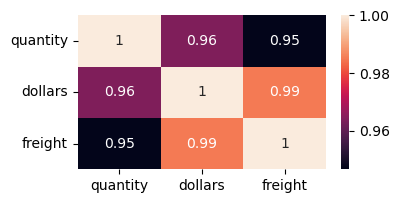

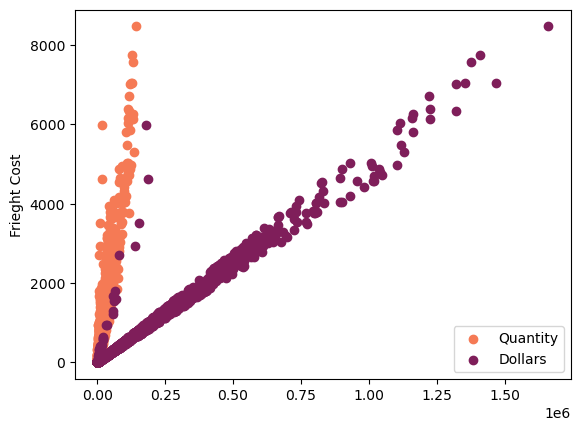

In [6]:
plt.figure(figsize = (4,2))
sns.heatmap(cor, annot = True)
plt.show()

plt.scatter(vendor_df['quantity'],vendor_df['freight'], color = '#f57a55')
plt.scatter(vendor_df['dollars'], vendor_df['freight'], color = '#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Frieght Cost')
plt.show()

In [7]:
vendor_df['freight_per_unit'] = vendor_df['freight']/vendor_df['quantity']

In [8]:
low_quantity = vendor_df['quantity'].quantile(0.25)
high_quantity = vendor_df['quantity'].quantile(0.75)

In [9]:
high_quantity, low_quantity

(5100.5, 83.0)

In [10]:
vendor_df.loc[vendor_df['quantity']<low_quantity,'freight_per_unit'].mean()

0.09489854253138316

In [11]:
vendor_df.loc[vendor_df['quantity']>high_quantity,'freight_per_unit'].mean()

0.049077654690759046

In [12]:
X = vendor_df[['dollars']]
y = vendor_df['freight']

In [13]:
vendor_df.describe().round()

,vendornumber,ponumber,quantity,dollars,freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


### Model Training

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4434, 1), (1109, 1), (4434,), (1109,))

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,   mean_squared_error, mean_absolute_error

In [17]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = DecisionTreeRegressor(max_depth=4, random_state=42)
model2.fit(X_train, y_train)

model3 = RandomForestRegressor(max_depth=4,random_state=42)
model3.fit(X_train, y_train)

RandomForestRegressor(max_depth=4, random_state=42)

In [18]:
def evaluate_model(model, X_test, y_test, model_name):
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred, squared = False)
    r2 = r2_score(y_test, pred) * 100

    print(f'{model_name} Performance:')
    print(f'MAE : {mae:.2f}')
    print(f'MSE : {mse:.2f}')
    print(f'R2 : {r2:.2f}%')
    print('-' * 60)

In [19]:
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regressor')
evaluate_model(model3, X_test, y_test, 'Random Forest Regressor')

Linear Regression Performance:
MAE : 24.11
MSE : 124.72
R2 : 96.99%
------------------------------------------------------------
Decision Tree Regressor Performance:
MAE : 38.12
MSE : 138.25
R2 : 96.30%
------------------------------------------------------------
Random Forest Regressor Performance:
MAE : 30.31
MSE : 130.66
R2 : 96.69%
------------------------------------------------------------


c:\Users\bhuvancw\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\bhuvancw\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\bhuvancw\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


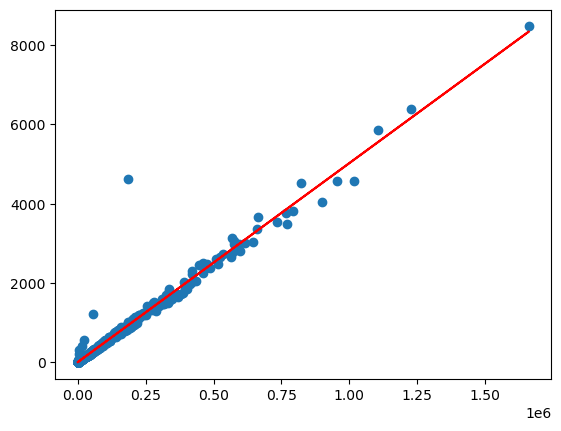

In [20]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test), color = 'r')

In [21]:
X_test.max()

dollars    1660435.88
dtype: float64

In [22]:
input_data = {
    'dollars':[18500, 9000]
}

df = pd.DataFrame(input_data)

model1.predict(df)

array([97.78868161, 50.14455838])

In [23]:
conn = sqlite3.connect(db_path)

query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)

print(tables)

conn.close()

NameError: name 'db_path' is not defined